In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer, KNNImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

## **Part A - Data Loading and Preprocessing with Scikit-learn**

### Task 1 - Load and Understand the Dataset

#### Load hotel_bookings.csv. Use head(), shape, info(), describe(), and dtypes.

In [99]:
df = pd.read_csv("hotel_bookings.csv")

In [100]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [101]:
df.shape

(119390, 32)

In [102]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [103]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [104]:
df.dtypes

hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type                          str
agent                             

#### Check the class distribution of is_canceled and use it as the target y.

In [105]:
df["is_canceled"].value_counts()

is_canceled
0    75166
1    44224
Name: count, dtype: int64

In [106]:
df["is_canceled"].value_counts(normalize=True) * 100

is_canceled
0    62.958372
1    37.041628
Name: proportion, dtype: float64

#### Create X from the remaining usable features. Identify numerical and categorical columns.

In [107]:
y = df["is_canceled"]
X = df.drop(columns=["is_canceled"])

In [108]:
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical columns:")
print(numerical_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numerical columns:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Categorical columns:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']


### Task 2 - Missing Values, Leakage, and Outliers

#### Find the missing-value count and percentage for every column.

In [109]:
missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

missing_summary = missing_summary.sort_values(
    by="Missing Percentage",
    ascending=False
)

missing_summary

,Missing Count,Missing Percentage
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350
arrival_date_month,0,0.000000
arrival_date_week_number,0,0.000000
hotel,0,0.000000
is_canceled,0,0.000000
stays_in_weekend_nights,0,0.000000
arrival_date_day_of_month,0,0.000000


#### Identify columns with very high missingness. Drop them only if justified and state the reason.

In [110]:
high_missing = missing_summary[missing_summary["Missing Percentage"] > 50]

high_missing

,Missing Count,Missing Percentage
company,112593,94.306893


Reason: company contains a very large proportion of missing values, so retaining it would provide little useful information and would require substantial imputation. It is therefore dropped.

In [111]:
df = df.drop(columns=["company"])

#### Remove columns that directly reveal the final booking outcome, such as reservation_status and reservation_status_date.

In [112]:
leakage_cols = ["reservation_status", "reservation_status_date"]

df = df.drop(columns=leakage_cols)

#### Check selected numerical features for outliers using boxplots and/or the IQR method.

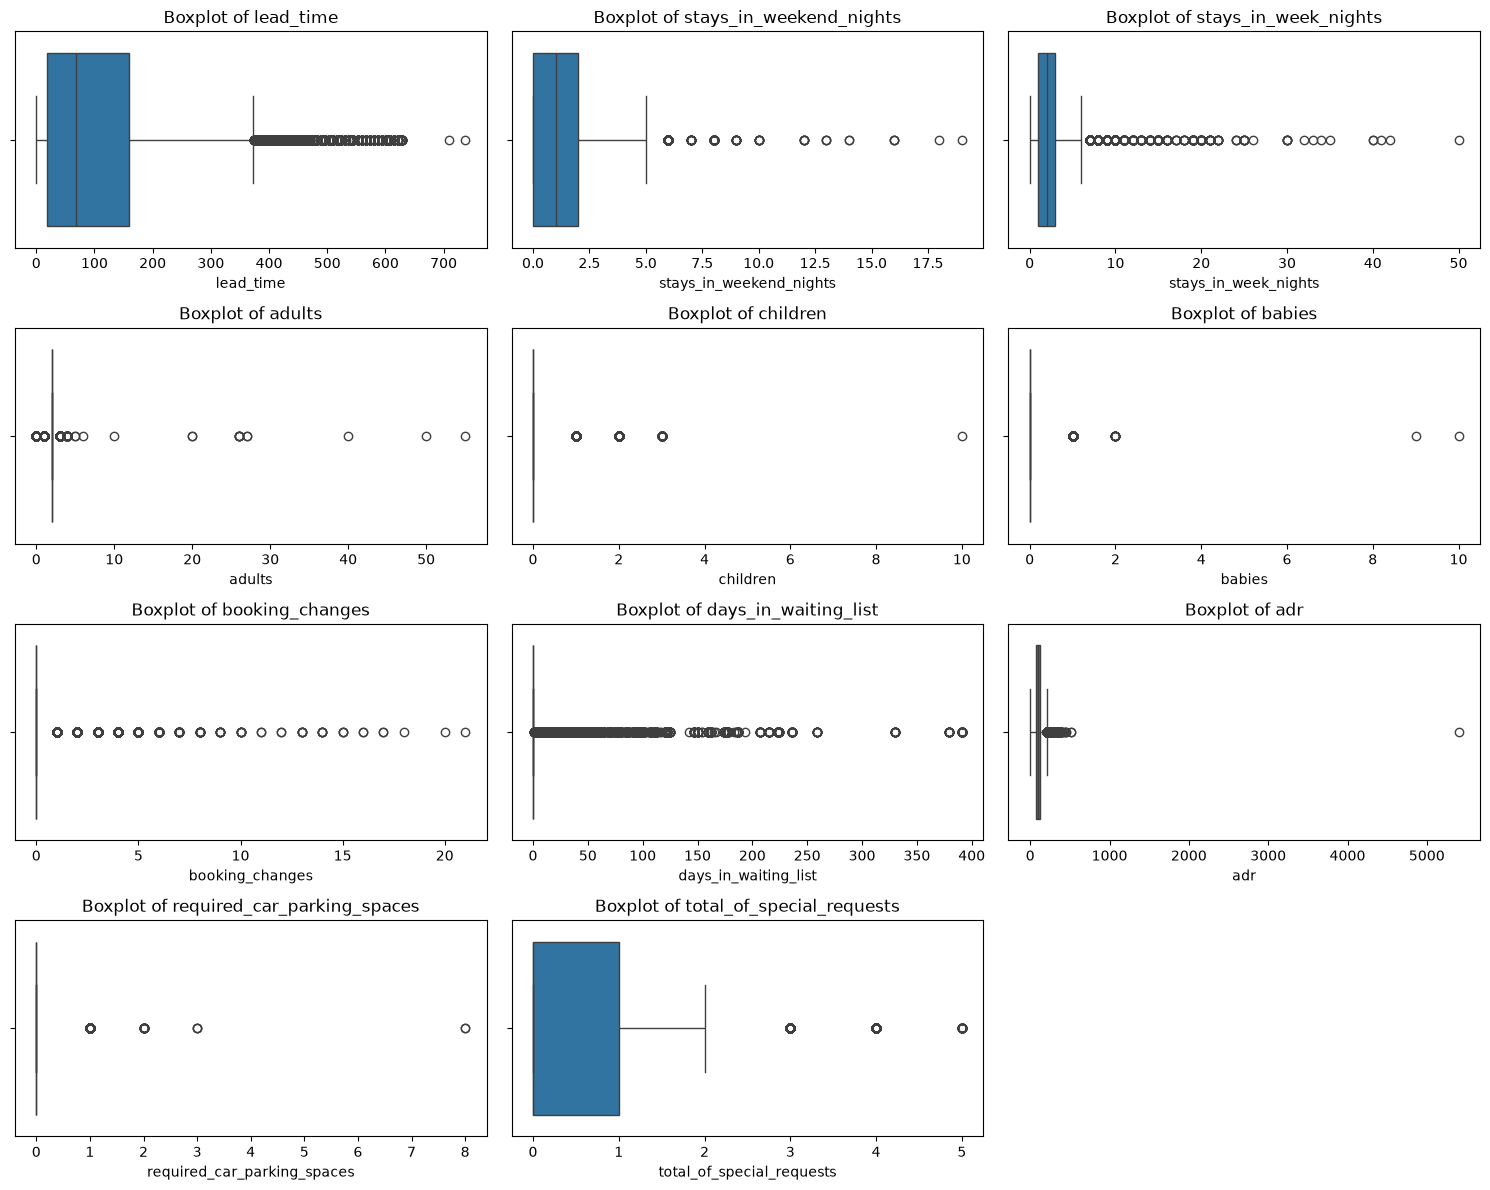

In [113]:
selected_numeric = [
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "booking_changes",
    "days_in_waiting_list",
    "adr",
    "required_car_parking_spaces",
    "total_of_special_requests",
]

plt.figure(figsize=(15, 12))

for i, col in enumerate(selected_numeric):
    plt.subplot(4, 3, i + 1) 
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()


#### Remove only clear/extreme outliers and report how many rows were removed.

In [114]:
rows_before = len(df)

df = df[
    (df["adults"] <= 10) &
    (df["children"] <= 3) &
    (df["babies"] <= 2) &
    (df["adr"] <= 1000)
].copy()

rows_removed = rows_before - len(df)

print("Rows removed:", rows_removed)
print("Rows remaining:", len(df))
df[["adults", "children", "babies", "adr"]].describe()

# Create X and y again after cleaning
y = df["is_canceled"]
X = df.drop(columns=["is_canceled"])

Rows removed: 20
Rows remaining: 119370


In [115]:
df[["adults", "children", "babies", "adr"]].describe()

,adults,children,babies,adr
count,119370.000000,119370.000000,119370.000000,119370.000000
mean,1.853489,0.103820,0.007791,101.799334
std,0.489677,0.397556,0.089340,48.144385
min,0.000000,0.000000,0.000000,-6.380000
25%,2.000000,0.000000,0.000000,69.290000
50%,2.000000,0.000000,0.000000,94.610000
75%,2.000000,0.000000,0.000000,126.000000
max,10.000000,3.000000,2.000000,510.000000


### Task 3 - Create Two Preprocessing Pipelines

#### Split the data using train_test_split(test_size=0.2, stratify=y, random_state=42). Use the same split for all experiments.

In [116]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (95496, 28)
Testing set: (23874, 28)


In [117]:
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical columns:", len(numerical_cols))
print("Categorical columns:", len(categorical_cols))

Numerical columns: 18
Categorical columns: 10


In [118]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

#### Pipeline A: KNNImputer + StandardScaler for numerical features.

#### For numerical columns, use KNNImputer(n_neighbors=5) for missing values.
#### For categorical columns, use SimpleImputer(strategy="most_frequent") and OneHotEncoder(handle_unknown="ignore").

In [119]:
numeric_pipeline_A = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", StandardScaler())
])

preprocessor_A = ColumnTransformer([
    ("num", numeric_pipeline_A, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

#### Pipeline B: KNNImputer + MinMaxScaler for numerical features.

#### Use ColumnTransformer and Pipeline so that preprocessing is fitted only on the training data.

In [120]:
numeric_pipeline_B = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", MinMaxScaler())
])

preprocessor_B = ColumnTransformer([
    ("num", numeric_pipeline_B, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

## **Part B - Model Training and Performance Evaluation**

### Task 4 - Train Two Classification Models

#### Keep the model settings and train-test split unchanged across the comparison.

In [121]:
X_train_A = preprocessor_A.fit_transform(X_train)
X_test_A = preprocessor_A.transform(X_test)

X_train_B = preprocessor_B.fit_transform(X_train)
X_test_B = preprocessor_B.transform(X_test)

print("Preprocessing completed.")

Preprocessing completed.


#### You should obtain four trained model-pipeline combinations in total.

#### Train LogisticRegression(max_iter=1000) using Pipeline A and Pipeline B.

#### Train DecisionTreeClassifier(random_state=42) using Pipeline A and Pipeline B.

In [122]:
logistic_A = LogisticRegression(max_iter=1000)
logistic_B = LogisticRegression(max_iter=1000)

tree_A = DecisionTreeClassifier(random_state=42)
tree_B = DecisionTreeClassifier(random_state=42)

logistic_A.fit(X_train_A, y_train)
logistic_B.fit(X_train_B, y_train)

tree_A.fit(X_train_A, y_train)
tree_B.fit(X_train_B, y_train)

print("All four models trained.")

All four models trained.


### Task 5 - Evaluate and Compare the Four Results

#### For each experiment, calculate training accuracy, testing accuracy, precision, recall, and F1-score.

In [123]:
y_train_lr_A = logistic_A.predict(X_train_A)
y_test_lr_A = logistic_A.predict(X_test_A)

y_train_lr_B = logistic_B.predict(X_train_B)
y_test_lr_B = logistic_B.predict(X_test_B)

y_train_tree_A = tree_A.predict(X_train_A)
y_test_tree_A = tree_A.predict(X_test_A)

y_train_tree_B = tree_B.predict(X_train_B)
y_test_tree_B = tree_B.predict(X_test_B)

print("Predictions completed.")

Predictions completed.


#### Create a final comparison table containing all four model-pipeline combinations.

In [124]:
results = []

experiments = [
    ("Logistic Regression - Pipeline A", y_train_lr_A, y_test_lr_A),
    ("Logistic Regression - Pipeline B", y_train_lr_B, y_test_lr_B),
    ("Decision Tree - Pipeline A", y_train_tree_A, y_test_tree_A),
    ("Decision Tree - Pipeline B", y_train_tree_B, y_test_tree_B)
]

for name, train_pred, test_pred in experiments:
    results.append({
        "Model-Pipeline": name,
        "Training Accuracy": accuracy_score(y_train, train_pred),
        "Testing Accuracy": accuracy_score(y_test, test_pred),
        "Precision": precision_score(y_test, test_pred),
        "Recall": recall_score(y_test, test_pred),
        "F1-Score": f1_score(y_test, test_pred)
    })

results_df = pd.DataFrame(results)

results_df["Train-Test Difference"] = (
    results_df["Training Accuracy"] - results_df["Testing Accuracy"]
)

results_df

,Model-Pipeline,Training Accuracy,Testing Accuracy,Precision,Recall,F1-Score,Train-Test Difference
0,Logistic Regression - Pipeline A,0.819019,0.818464,0.807813,0.668929,0.731840,0.000555
1,Logistic Regression - Pipeline B,0.814118,0.813856,0.802282,0.659993,0.724215,0.000262
2,Decision Tree - Pipeline A,0.996157,0.860183,0.808015,0.816423,0.812198,0.135974
3,Decision Tree - Pipeline B,0.996157,0.860266,0.807783,0.817102,0.812416,0.135891


#### Plot a confusion matrix for the best Logistic Regression result and the best Decision Tree result.

In [125]:
best_lr = results_df[
    results_df["Model-Pipeline"].str.startswith("Logistic Regression")
].sort_values("F1-Score", ascending=False).iloc[0]

best_tree = results_df[
    results_df["Model-Pipeline"].str.startswith("Decision Tree")
].sort_values("F1-Score", ascending=False).iloc[0]

print("Best Logistic Regression:", best_lr["Model-Pipeline"])
print("Best Decision Tree:", best_tree["Model-Pipeline"])

Best Logistic Regression: Logistic Regression - Pipeline A
Best Decision Tree: Decision Tree - Pipeline B


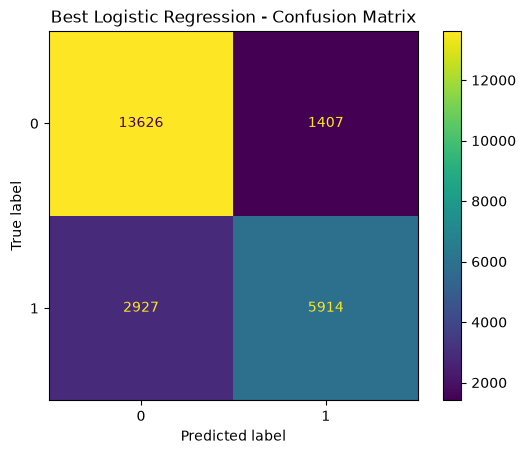

In [126]:
if best_lr["Model-Pipeline"] == "Logistic Regression - Pipeline A":
    ConfusionMatrixDisplay.from_predictions(y_test, y_test_lr_A)
else:
    ConfusionMatrixDisplay.from_predictions(y_test, y_test_lr_B)

plt.title("Best Logistic Regression - Confusion Matrix")
plt.show()

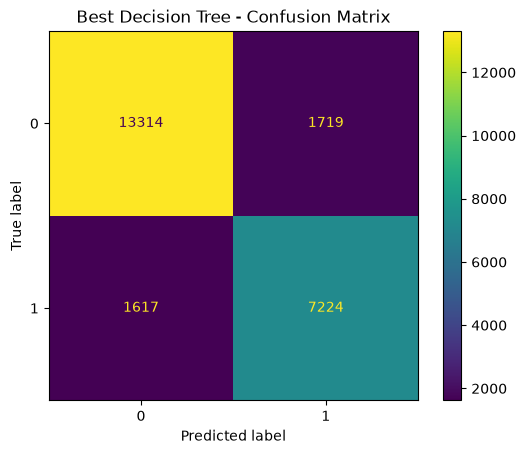

In [127]:
if best_tree["Model-Pipeline"] == "Decision Tree - Pipeline A":
    ConfusionMatrixDisplay.from_predictions(y_test, y_test_tree_A)
else:
    ConfusionMatrixDisplay.from_predictions(y_test, y_test_tree_B)

plt.title("Best Decision Tree - Confusion Matrix")
plt.show()

#### Use the train-test performance difference to comment briefly on possible overfitting.

In [128]:
for _, row in results_df.iterrows():
    print(
        row["Model-Pipeline"],
        "-> Train-Test Difference:",
        round(row["Train-Test Difference"], 4)
    )

Logistic Regression - Pipeline A -> Train-Test Difference: 0.0006
Logistic Regression - Pipeline B -> Train-Test Difference: 0.0003
Decision Tree - Pipeline A -> Train-Test Difference: 0.136
Decision Tree - Pipeline B -> Train-Test Difference: 0.1359


### Task 6 - Final Observations

#### **Which preprocessing-model combination gives the best overall result?**

The Decision Tree with Pipeline B (KNNImputer + MinMaxScaler) gives the best overall result. It has the highest testing accuracy (86.03%) and highest F1-score (0.8124), along with the highest recall (81.71%).

#### **Does StandardScaler or MinMaxScaler affect Logistic Regression more?**
StandardScaler performs slightly better than MinMaxScaler for Logistic Regression. Pipeline A has higher testing accuracy (81.85% vs 81.39%) and F1-score (0.7318 vs 0.7242). Therefore, StandardScaler gives Logistic Regression a small performance improvement.

#### **Does scaling make a major difference for the Decision Tree? Comment briefly.**
Scaling makes almost no difference to the Decision Tree. Pipeline A and Pipeline B have nearly identical testing accuracy (86.02% vs 86.03%) and F1-score (0.8122 vs 0.8124). This shows that Decision Trees are largely unaffected by feature scaling.

#### **Write 4-5 short observations supported by the performance table and confusion matrices.**
1. Decision Tree performs better than Logistic Regression, achieving about 86.03% testing accuracy compared with 81.85% for the best Logistic Regression model.
2. Pipeline A is slightly better for Logistic Regression, while Pipeline B is very slightly better for the Decision Tree. The differences are small.
3. The Decision Tree has a large train-test difference of about 13.6 percentage points, indicating considerable overfitting.
4. Logistic Regression has very small train-test differences (0.06% and 0.03%), indicating that it does not show significant overfitting.
5. The Decision Tree has substantially higher recall (~81.7%) and F1-score (~81.2%) than Logistic Regression, meaning it is better at identifying canceled bookings while maintaining a good balance between precision and recall.